# Librerias

In [1]:
# importo todo lo que necesito para este notebook
import cv2
import numpy as np
import json
import pickle
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

# inicializo el modelo de InsightFace con ArcFace
# ctx_id=-1 significa CPU, 0 sería GPU
app = FaceAnalysis(name="buffalo_l", providers=["CPUExecutionProvider"])
app.prepare(ctx_id=-1, det_size=(640, 640))

print("✅ InsightFace listo")
print(f"Modelos cargados: {list(app.models.keys())}")

download_path: /Users/mynorhm/.insightface/models/buffalo_l


100%|███████████████████████████████| 281857/281857 [00:14<00:00, 19858.78KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mynorhm/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mynorhm/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mynorhm/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mynorhm/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/mynorhm/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

✅ Cara detectada
   Embedding shape: (512,)
   Bbox: [ 751  218 1190  842]
   Confianza: 0.85


/Users/mynorhm/Desktop/MIOTI/Master en Deep Learning/MDL_CV_Computer Vision/ProyecoFinal/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


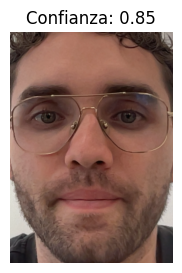

In [2]:
# capturo un frame de la cámara y extraigo el embedding de mi cara
CAMARA_INDEX = 0  # ajusta si es necesario

cap = cv2.VideoCapture(CAMARA_INDEX)
for _ in range(10):
    ret, frame = cap.read()
cap.release()

# insightface trabaja en BGR, que es como OpenCV devuelve los frames
faces = app.get(frame)

if not faces:
    print("❌ No se detectó ninguna cara")
else:
    face = faces[0]
    embedding = face.embedding  # vector de 512 dimensiones
    print(f"✅ Cara detectada")
    print(f"   Embedding shape: {embedding.shape}")
    print(f"   Bbox: {face.bbox.astype(int)}")
    print(f"   Confianza: {face.det_score:.2f}")

# muestro la cara recortada
x1, y1, x2, y2 = face.bbox.astype(int)
cara_recortada = frame[y1:y2, x1:x2]
cara_rgb = cv2.cvtColor(cara_recortada, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(3, 3))
plt.imshow(cara_rgb)
plt.title(f"Confianza: {face.det_score:.2f}")
plt.axis("off")
plt.show()

In [3]:
# función para registrar una persona en la whitelist
# toma varias fotos para que el embedding sea más robusto
def registrar_persona(nombre, n_fotos=5, camara_index=0):
    print(f"📸 Registrando a: {nombre}")
    print(f"   Mira a la cámara, voy a capturar {n_fotos} fotos...")
    
    embeddings = []
    cap = cv2.VideoCapture(camara_index)
    
    for i in range(n_fotos):
        input(f"   Enter para capturar foto {i+1}/{n_fotos}...")
        
        for _ in range(10):
            ret, frame = cap.read()
        
        faces = app.get(frame)
        
        if not faces:
            print(f"   ⚠️ No detecté cara en foto {i+1}, saltando...")
            continue
        
        emb = faces[0].embedding
        embeddings.append(emb)
        print(f"   ✅ Foto {i+1} capturada — confianza: {faces[0].det_score:.2f}")
    
    cap.release()
    
    if not embeddings:
        print("❌ No se pudo registrar, ninguna foto válida")
        return None
    
    # promedio de todos los embeddings para mayor robustez
    embedding_final = np.mean(embeddings, axis=0)
    
    # guardo en la whitelist
    whitelist_path = Path("whitelist/whitelist.pkl")
    if whitelist_path.exists():
        with open(whitelist_path, "rb") as f:
            whitelist = pickle.load(f)
    else:
        whitelist = {}
    
    whitelist[nombre] = embedding_final
    
    with open(whitelist_path, "wb") as f:
        pickle.dump(whitelist, f)
    
    print(f"\n✅ {nombre} registrado con {len(embeddings)} fotos")
    print(f"   Whitelist actual: {list(whitelist.keys())}")
    return embedding_final

# registro tu cara
registrar_persona("Mynor")

📸 Registrando a: Mynor
   Mira a la cámara, voy a capturar 5 fotos...


   Enter para capturar foto 1/5... 


   ✅ Foto 1 capturada — confianza: 0.82


/Users/mynorhm/Desktop/MIOTI/Master en Deep Learning/MDL_CV_Computer Vision/ProyecoFinal/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


   Enter para capturar foto 2/5... 


...

   Enter para capturar foto 4/5... 


   ✅ Foto 4 capturada — confianza: 0.81


   Enter para capturar foto 5/5... 


   ✅ Foto 5 capturada — confianza: 0.81

✅ Mynor registrado con 5 fotos
   Whitelist actual: ['Mynor']


array([ 1.24407363e+00, -4.54524904e-01,  5.55318236e-01,  1.13562393e+00,
        3.91272426e-01,  1.80562824e-01, -8.63902122e-02, -4.61543977e-01,
       -7.58847952e-01,  3.31506431e-01,  6.57989502e-01, -1.89701939e+00,
       -1.62115765e+00,  4.85556513e-01, -1.05636048e+00, -9.08140659e-01,
        1.67477679e+00,  8.11006904e-01, -1.13308084e+00,  2.68317819e-01,
        7.98355877e-01, -1.09528027e-01, -5.91568530e-01,  2.84072161e-01,
        6.73859477e-01, -1.71883142e+00, -8.67930412e-01, -2.23145819e+00,
        3.04421365e-01,  2.33104539e+00,  2.71426618e-01, -1.22330391e+00,
       -7.98290133e-01, -2.35837936e+00,  1.10778081e+00,  1.22220111e+00,
        8.78893286e-02,  1.12293434e+00, -1.38032734e+00, -7.48880506e-01,
        1.83827847e-01,  8.40544343e-01, -9.65832591e-01,  4.56827641e-01,
        7.25206792e-01,  1.21922839e+00,  9.76491645e-02, -4.06424612e-01,
       -3.55413198e-01,  5.41350007e-01, -1.73903787e+00, -1.91831565e+00,
       -3.43853176e-01, -

In [7]:
# función que dado un frame decide si la cara es de alguien de la whitelist o un intruso
def reconocer_cara(frame, umbral=0.5):
    # cargo la whitelist
    whitelist_path = Path("whitelist/whitelist.pkl")
    if not whitelist_path.exists():
        print("❌ Whitelist vacía, registra personas primero")
        return []
    
    with open(whitelist_path, "rb") as f:
        whitelist = pickle.load(f)
    
    faces = app.get(frame)
    resultados = []
    
    for face in faces:
        emb = face.embedding.reshape(1, -1)
        mejor_nombre = "Intruso"
        mejor_score = 0.0
        
        # comparo contra cada persona de la whitelist
        for nombre, emb_ref in whitelist.items():
            score = cosine_similarity(emb, emb_ref.reshape(1, -1))[0][0]
            if score > mejor_score:
                mejor_score = score
                mejor_nombre = nombre if score >= umbral else "Intruso"
        
        resultados.append({
            "nombre": mejor_nombre,
            "score": mejor_score,
            "bbox": face.bbox.astype(int),
            "autorizado": mejor_nombre != "Intruso"
        })
    
    return resultados

# pruebo con un frame de la cámara
cap = cv2.VideoCapture(0)
for _ in range(10):
    ret, frame = cap.read()
cap.release()

resultados = reconocer_cara(frame)

for r in resultados:
    estado = "✅ Autorizado" if r["autorizado"] else "🚨 Intruso"
    print(f"{estado} — {r['nombre']} (score: {r['score']:.3f})")

🚨 Intruso — Intruso (score: 0.045)


/Users/mynorhm/Desktop/MIOTI/Master en Deep Learning/MDL_CV_Computer Vision/ProyecoFinal/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


/Users/mynorhm/Desktop/MIOTI/Master en Deep Learning/MDL_CV_Computer Vision/ProyecoFinal/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


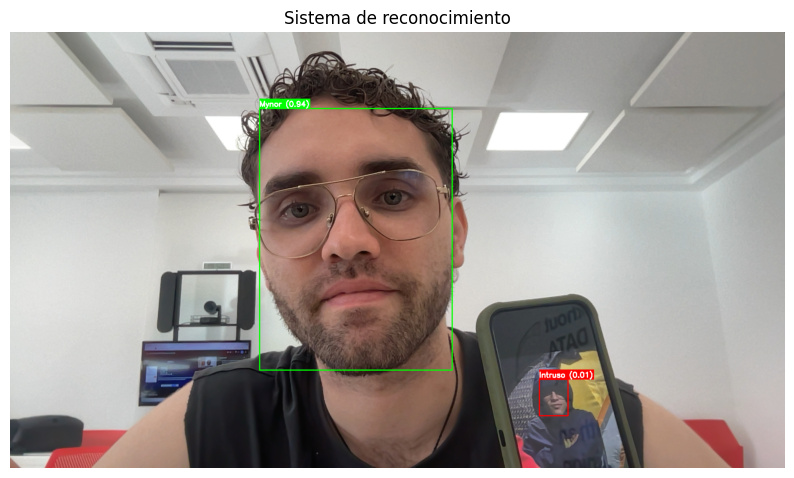

In [9]:
# dibujo los bounding boxes con el nombre y score sobre el frame
def dibujar_resultados(frame, resultados):
    frame_viz = frame.copy()
    
    for r in resultados:
        x1, y1, x2, y2 = r["bbox"]
        nombre = r["nombre"]
        score = r["score"]
        autorizado = r["autorizado"]
        
        # verde si autorizado, rojo si intruso
        color = (0, 255, 0) if autorizado else (0, 0, 255)
        
        # bbox
        cv2.rectangle(frame_viz, (x1, y1), (x2, y2), color, 2)
        
        # etiqueta con fondo
        label = f"{nombre} ({score:.2f})"
        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame_viz, (x1, y1 - h - 10), (x1 + w, y1), color, -1)
        cv2.putText(frame_viz, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return frame_viz

# pruebo con un frame nuevo
cap = cv2.VideoCapture(0)
for _ in range(10):
    ret, frame = cap.read()
cap.release()

resultados = reconocer_cara(frame)
frame_viz = dibujar_resultados(frame, resultados)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame_viz, cv2.COLOR_BGR2RGB))
plt.title("Sistema de reconocimiento")
plt.axis("off")
plt.show()